# Support Vector Machines (SVM) in Classification Tasks

## Linear SVM Classification

Let's generate linearly separable dataset with 2 centers and 300 samples of data:

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=2, cluster_std=0.60, random_state=0)

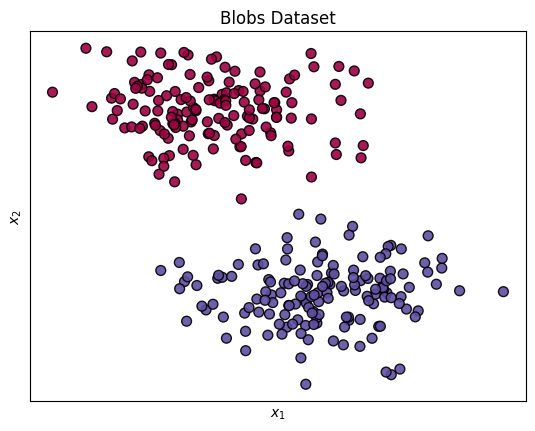

In [2]:
import matplotlib.pyplot as plt

def plot_data(X, y, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, alpha=0.9, edgecolor='black', cmap='Spectral')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_xticks([])
    ax.set_yticks([])

plot_data(X, y)
plt.title('Blobs Dataset')
plt.show()

#### Understanding Hyperparameter C
The C parameter controls the trade-off between maximizing the margin and minimizing training errors. 
Lower C values allow more flexible boundaries, while higher C values enforce stricter classification.

In [3]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

linear_svm_clf_c1 = Pipeline([('scaler', StandardScaler()),
                           ('linear_svc', LinearSVC(random_state=622, C=1))])

linear_svm_clf_c100 = Pipeline([('scaler', StandardScaler()),
                           ('linear_svc', LinearSVC(random_state=622, C=100))])

linear_svm_clf_c1.fit(X, y)

linear_svm_clf_c100.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('linear_svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [4]:
from sklearn.inspection import DecisionBoundaryDisplay

def plot_predictions(clf,X ,ax = None):

    if ax is None:
        ax = plt.gca()
    
    DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    plot_method='contour',
    response_method='decision_function',
    colors='k',
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--'],
    ax=ax,
    )
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method='predict',
        cmap='Spectral',
        alpha=0.3,
        ax = ax,
    )


#### Visualizing Decision Boundaries
The following function plots the decision boundary and margin lines of the trained SVM models.

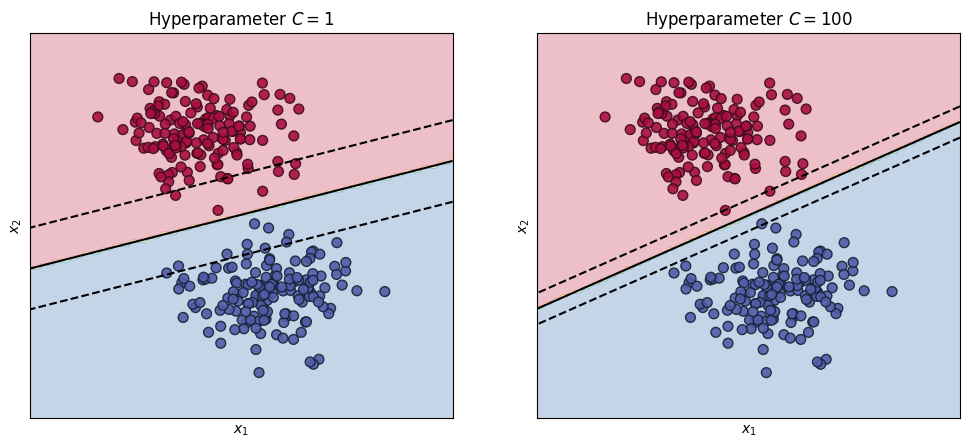

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.title('Hyperparameter $C=1$')
plot_data(X, y)
plot_predictions(linear_svm_clf_c1, X)

plt.subplot(122)
plt.title('Hyperparameter $C=100$')
plot_data(X, y)
plot_predictions(linear_svm_clf_c100, X)
plt.show()


#### Non-Linearly Separable Data
Real-world data often cannot be perfectly separated by a linear boundary. 
Let's now explore this scenario with higher cluster overlap.

In [6]:
X, y = make_blobs(n_samples=400, centers=2, cluster_std=1.2, random_state=0)

In [7]:
linear_svc_clf = Pipeline([('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(random_state=622))])

#### Hyperparameter Tuning with RandomizedSearchCV
Let's use RandomizedSearchCV to find the optimal C value for this more complex dataset.

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

linear_svc_param_distributions = {
    'linear_svc__C': randint(low=1, high=100)}

linear_svc_search = RandomizedSearchCV(linear_svc_clf, linear_svc_param_distributions, n_iter=100, cv=5, random_state=622)

linear_svc_search.fit(X, y)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=622))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'linear_svc__C': <scipy.stats....002F96A4C3010>}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",

In [9]:
linear_svc_search.best_params_

{'linear_svc__C': 56}

#### Why Nonlinear Kernels Matter
Linear SVM works well for linearly separable data, but struggles with complex patterns. 
Nonlinear kernels (Polynomial, RBF, Sigmoid) can handle more intricate decision boundaries.

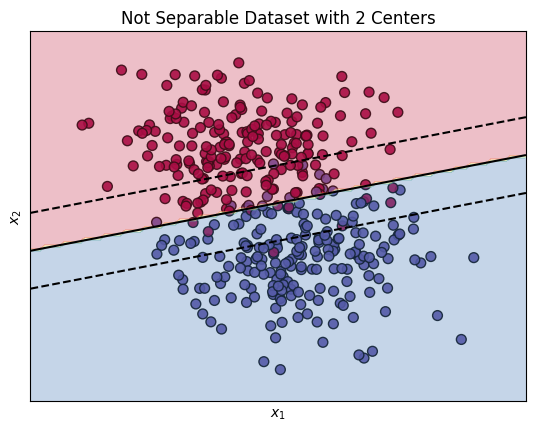

In [10]:
plot_data(X, y)
plt.title('Not Separable Dataset with 2 Centers')
plot_predictions(linear_svc_search.best_estimator_, X)

---

## Nonlinear SVM Classification

Let's generate 400 samples of data with 4 centers:

In [11]:
X, y = make_blobs(n_samples=400, centers=4, cluster_std=0.8, random_state=30)

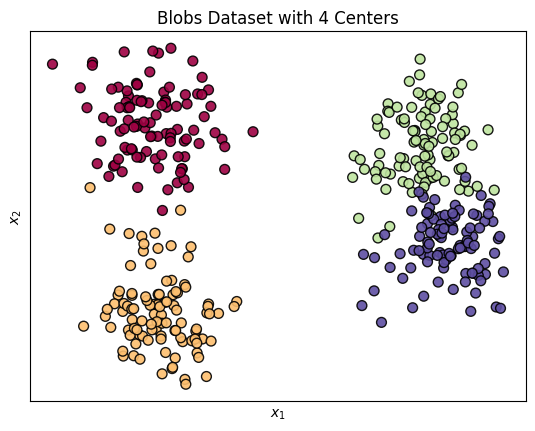

In [12]:
plot_data(X, y)
plt.title('Blobs Dataset with 4 Centers')
plt.show()

#### Comparing Kernel Types
Let's define models with different kernel types and hyperparameters, then compare their performance on multi-class data.

In [13]:
from sklearn.svm import SVC
from scipy.stats import randint, uniform

models = {
    'linear': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear'))
    ]),
    
    'poly': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='poly'))
    ]),
    
    'rbf': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf'))
    ]),
    
    'sigmoid': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='sigmoid'))
    ])
}

param_distributions = {

    'linear': {
        'svc__C': uniform(0.01, 100),
    },

    'poly': {
        'svc__C': uniform(0.01, 100),
        'svc__degree': randint(low=1, high=10),
        'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svc__coef0': uniform(-5, 10),
    },

    'rbf': {
        'svc__C': uniform(0.01, 100),
        'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    },

    'sigmoid': {
        'svc__C': uniform(0.01, 100),
        'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'svc__coef0': uniform(-5, 10),
    }
}

best_models = {}

for name in models:
    
    search = RandomizedSearchCV(
        models[name],
        param_distributions[name],
        n_iter=100,
        cv=5,
        random_state=622,
        n_jobs=-1
    )

    search.fit(X, y)
    
    best_models[name] = search.best_estimator_
    
    print(f'{name} best params:', search.best_params_)

linear best params: {'svc__C': np.float64(9.868966809397918)}
poly best params: {'svc__C': np.float64(66.0756610644477), 'svc__coef0': np.float64(3.7143952809135072), 'svc__degree': 7, 'svc__gamma': 0.01}
rbf best params: {'svc__C': np.float64(5.272693532228091), 'svc__gamma': 1}
sigmoid best params: {'svc__C': np.float64(28.20099472651231), 'svc__coef0': np.float64(2.7061774808459003), 'svc__gamma': 'auto'}


#### Decision Boundary Comparison
Below are the decision boundaries learned by each kernel type on the 4-center dataset:

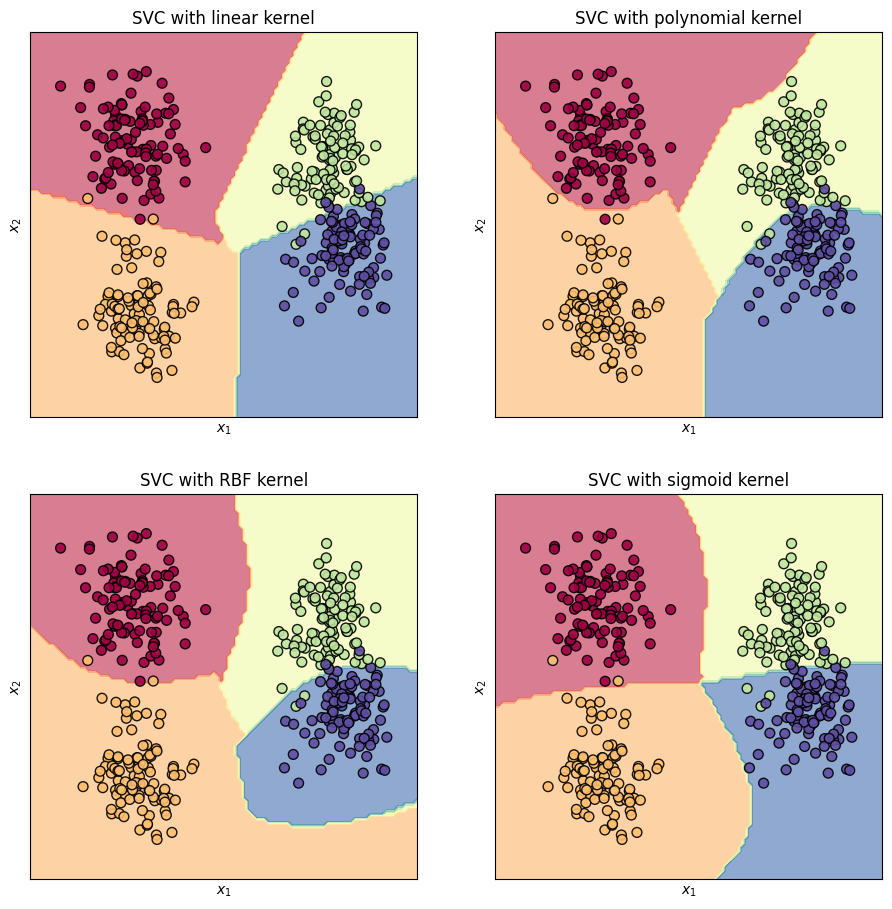

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

titles = ('SVC with linear kernel',
          'SVC with polynomial kernel',
          'SVC with RBF kernel',
          'SVC with sigmoid kernel')


fig, axes = plt.subplots(2, 2, figsize=(11, 11))

for model, title, ax in zip(best_models.values(), titles, axes.flatten()):

    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method='predict',
        cmap='Spectral',
        alpha=0.6,
        ax= ax,
    )
    ax.set_title(title)
    plot_data(X, y, ax)

plt.show()

---